# **CAT VS DOG CLASSIFICATION**

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import zipfile

ZIP_PATH = '/content/drive/MyDrive/archive.zip'  # update if your file name is different
DATASET_PATH = '/content/drive/MyDrive/Cat_Dog_Dataset'  # folder to extract into

with zipfile.ZipFile(ZIP_PATH, 'r') as zip_ref:
    zip_ref.extractall(DATASET_PATH)

KeyboardInterrupt: 

In [ ]:
import os

DATASET_PATH = '/content/drive/MyDrive/Cat_Dog_Dataset/'

print("Train cats:", len(os.listdir(DATASET_PATH + 'training_set/training_set/cats')))
print("Train dogs:", len(os.listdir(DATASET_PATH + 'training_set/training_set/dogs')))
print("Test cats:", len(os.listdir(DATASET_PATH + 'test_set/test_set/cats')))
print("Test dogs:", len(os.listdir(DATASET_PATH + 'test_set/test_set/dogs')))

Train cats: 4001
Train dogs: 4006
Test cats: 1012
Test dogs: 1013


In [ ]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Data augmentation for training images
TRAIN_DATAGEN = ImageDataGenerator(
    rescale=1./255,          # normalize pixel values
    shear_range=0.2,         # small random shear
    zoom_range=0.2,          # small random zoom
    horizontal_flip=True     # flip images horizontally
)

# Only normalization for test images
TEST_DATAGEN = ImageDataGenerator(rescale=1./255)

# Load training images
TRAINING_SET = TRAIN_DATAGEN.flow_from_directory(
    '/content/drive/MyDrive/Cat_Dog_Dataset/training_set/training_set',  # path to train folder
    target_size=(128, 128),  # resize images
    batch_size=32,
    class_mode='binary'      # binary classification (cat/dog)
)

# Load testing images
TEST_SET = TEST_DATAGEN.flow_from_directory(
    '/content/drive/MyDrive/Cat_Dog_Dataset/test_set/test_set',  # path to test folder
    target_size=(128, 128),
    batch_size=32,
    class_mode='binary'
)

Found 8005 images belonging to 2 classes.
Found 2023 images belonging to 2 classes.


Cleaning training directory...
Cleaning testing directory...
Found 8005 images belonging to 2 classes.
Found 2022 images belonging to 2 classes.
Epoch 1/25
251/251 ━━━━━━━━━━━━━━━━━━━━ 570s 2s/step - accuracy: 0.5302 - loss: 1.3761 - val_accuracy: 0.5282 - val_loss: 0.7157
Epoch 2/25
251/251 ━━━━━━━━━━━━━━━━━━━━ 561s 2s/step - accuracy: 0.5461 - loss: 0.7501 - val_accuracy: 0.6108 - val_loss: 0.6593
Epoch 3/25
251/251 ━━━━━━━━━━━━━━━━━━━━ 561s 2s/step - accuracy: 0.5874 - loss: 0.6910 - val_accuracy: 0.5415 - val_loss: 0.6901
Epoch 4/25
251/251 ━━━━━━━━━━━━━━━━━━━━ 562s 2s/step - accuracy: 0.5980 - loss: 0.6619 - val_accuracy: 0.6469 - val_loss: 0.6411
Epoch 5/25
251/251 ━━━━━━━━━━━━━━━━━━━━ 570s 2s/step - accuracy: 0.6429 - loss: 0.6383 - val_accuracy: 0.5134 - val_loss: 0.7082
Epoch 6/25
251/251 ━━━━━━━━━━━━━━━━━━━━ 563s 2s/step - accuracy: 0.6767 - loss: 0.5993 - val_accuracy: 0.6919 - val_loss: 0.5851
Epoch 7/25
251/251 ━━━━━━━━━━━━━━━━━━━━ 558s 2s/step - accuracy: 0.6846 - loss: 0


✅ Final Training Accuracy: 87.47%
✅ Final Validation Accuracy: 88.43%


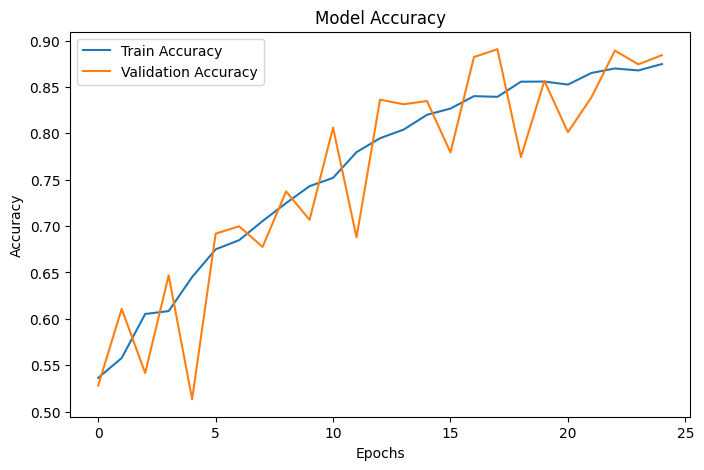

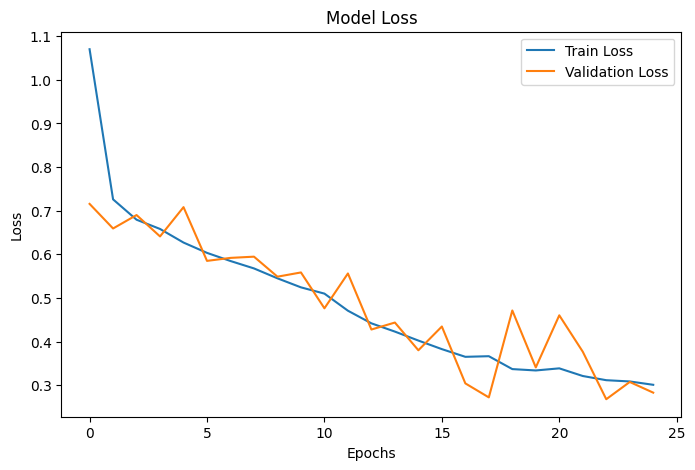

In [ ]:
# Step 1: Import Libraries
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, BatchNormalization
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import os
from PIL import Image
import matplotlib.pyplot as plt

# Step 2: Prepare Data

# Function to check if a file is a valid image
def is_image_file(filepath):
    try:
        Image.open(filepath)
        return True
    except IOError:
        return False

# Define base directories
DATASET_PATH = '/content/drive/MyDrive/Cat_Dog_Dataset/'
TRAIN_DIR = os.path.join(DATASET_PATH, 'training_set', 'training_set')
TEST_DIR = os.path.join(DATASET_PATH, 'test_set', 'test_set')

# Function to clean directories by removing non-image files
def clean_directory(directory):
    for subdir, _, files in os.walk(directory):
        for file in files:
            filepath = os.path.join(subdir, file)
            if not is_image_file(filepath):
                print(f"Removing non-image file: {filepath}")
                os.remove(filepath)

print("Cleaning training directory...")
clean_directory(TRAIN_DIR)
print("Cleaning testing directory...")
clean_directory(TEST_DIR)

# Image augmentation for better generalization
TRAIN_DATAGEN = ImageDataGenerator(
    rescale=1./255,
    shear_range=0.2,
    zoom_range=0.3,
    rotation_range=20,
    width_shift_range=0.2,
    height_shift_range=0.2,
    horizontal_flip=True
)

TEST_DATAGEN = ImageDataGenerator(rescale=1./255)

TRAINING_SET = TRAIN_DATAGEN.flow_from_directory(
    TRAIN_DIR,
    target_size=(128, 128),
    batch_size=32,
    class_mode='binary'
)

TEST_SET = TEST_DATAGEN.flow_from_directory(
    TEST_DIR,
    target_size=(128, 128),
    batch_size=32,
    class_mode='binary'
)

# Step 3: Build the Improved CNN Model
MODEL = Sequential()

# 1st Convolution Block
MODEL.add(Conv2D(32, (3,3), activation='relu', input_shape=(128,128,3)))
MODEL.add(BatchNormalization())
MODEL.add(MaxPooling2D(pool_size=(2,2)))

# 2nd Convolution Block
MODEL.add(Conv2D(64, (3,3), activation='relu'))
MODEL.add(BatchNormalization())
MODEL.add(MaxPooling2D(pool_size=(2,2)))

# 3rd Convolution Block
MODEL.add(Conv2D(128, (3,3), activation='relu'))
MODEL.add(BatchNormalization())
MODEL.add(MaxPooling2D(pool_size=(2,2)))

# 4th Convolution Block (extra layer for better accuracy)
MODEL.add(Conv2D(256, (3,3), activation='relu'))
MODEL.add(BatchNormalization())
MODEL.add(MaxPooling2D(pool_size=(2,2)))

# Flatten and Dense Layers
MODEL.add(Flatten())
MODEL.add(Dense(256, activation='relu'))
MODEL.add(Dropout(0.5))
MODEL.add(Dense(128, activation='relu'))
MODEL.add(Dropout(0.3))
MODEL.add(Dense(1, activation='sigmoid'))  # Binary output

# Step 4: Compile Model
MODEL.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# Step 5: Train the Model
history = MODEL.fit(
    TRAINING_SET,
    steps_per_epoch=len(TRAINING_SET),
    epochs=25,  # increased epochs for higher accuracy
    validation_data=TEST_SET,
    validation_steps=len(TEST_SET)
)

# Step 6: Print Final Accuracy
TRAIN_ACC = history.history['accuracy'][-1] * 100
VAL_ACC = history.history['val_accuracy'][-1] * 100

print("\n✅ Final Training Accuracy: {:.2f}%".format(TRAIN_ACC))
print("✅ Final Validation Accuracy: {:.2f}%".format(VAL_ACC))

# Step 7: Save the Model
MODEL.save('/content/drive/MyDrive/cat_dog_cnn_model_improved.h5')

# Step 8: Plot Accuracy and Loss Graphs
plt.figure(figsize=(8,5))
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

plt.figure(figsize=(8,5))
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

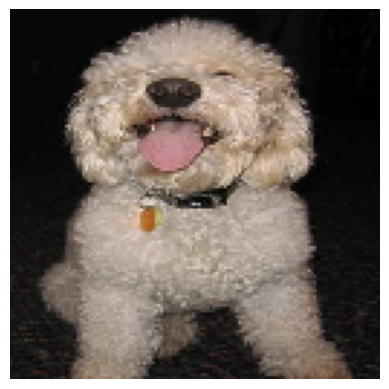

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 141ms/step
Predicted:Dog 🐶


In [ ]:
from tensorflow.keras.preprocessing import image
import numpy as np
from tensorflow.keras.models import load_model
import matplotlib.pyplot as plt

# Load the trained model
MODEL = load_model('/content/drive/MyDrive/cat_dog_cnn_model.h5')
print("Model loaded successfully ✅")

# Load a single test image (change path to your actual image)
IMG_PATH = '/content/drive/MyDrive/Cat_Dog_Dataset/test_set/test_set/dogs/dog.4003.jpg'
IMG = image.load_img(IMG_PATH, target_size=(128,128))

# Show the image
plt.imshow(IMG)
plt.axis('off')
plt.show()

# Preprocess the image
IMG_ARRAY = image.img_to_array(IMG)
IMG_ARRAY = np.expand_dims(IMG_ARRAY, axis=0)
IMG_ARRAY /= 255.0

# Make prediction
PREDICTION = MODEL.predict(IMG_ARRAY)

# Print result
if PREDICTION[0][0] > 0.5:
    print("Predicted:Dog ")
else:
    print("Predicted:Cat ")